In [66]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [67]:
def f(x):
    return 3 * x **2 - 4 *x +5

In [68]:
f(3)

20

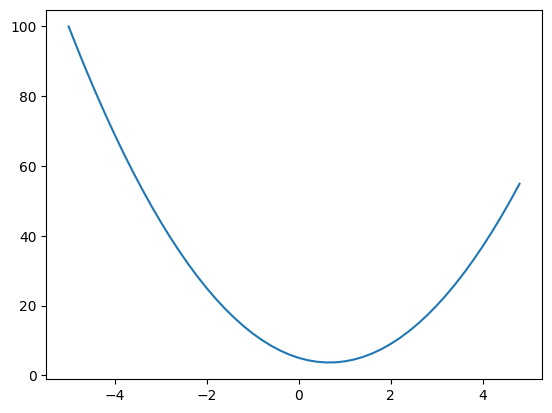

In [69]:
xs = np.arange(-5,5, 0.2)
ys = f(xs)
plt.plot(xs,ys)

In [70]:
h = 0.000000001
x = -3
(f(x+h) - f(x))/h

-22.000001820288162

In [71]:
# go more complex
a =2.0
b = -3.0
c = 10.0
d = a *b +c
print(d)

4.0


In [72]:
h = 0.00001
a =2.0
b = -3.0
c = 10.0
d1 = a *b +c
c += h
d2 = a *b +c
print('d1', d1)
print('d2', d2)
print('slope', (d2-d1)/h)

d1 4.0
d2 4.00001
slope 0.9999999999621422


In [107]:
class Value:

    def __init__(self, data, _children = (), _op= '', label = ''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self.label = label
        self.grad = 0
        self._backward = lambda: None 

    def __repr__(self):
        return f"Value(data={self.data}, op={self._op})" 

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad += out.grad * 1.0
            other.grad += out.grad * 1.0
        out._backward = _backward
        return out

    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += out.grad * other.data
            other.grad += out.grad * self.data
        out._backward = _backward
        return out

    def tanh(self):
        n = self.data
        t = (math.exp(2*n) - 1 ) / (math.exp(2*n) + 1)
        out = Value(t, (self, ), 'tanh')
        def _backward():
            self.grad += out.grad * (1- t**2)
        out._backward = _backward

        return out
    
    def backward(self):
        # topological sort
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                topo.append(v) # reverse (noramlly after the for)
                for child in v._prev:
                    build_topo(child)
        build_topo(self)
        self.grad = 1
        for node in topo:
            node._backward()

a = Value(2.0)
b = Value(-3)
a + b # same as a.__add__(b)
a * b

Value(data=-6.0, op=*)

In [93]:
a = Value(2.0, label = 'a')
b = Value(-3.0, label = 'b')
c = Value(10.0, label = 'c')
e = a *b ; e.label = 'e'
d = e+c; d.label = 'd'
f = Value(-2, label = 'f')
L = d * f; L.label = 'L'

### Need to install graphviz
- pip install graphviz
- sudo apt update
- sudo apt install graphviz -y

Check by running:
- dot -V


In [94]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{%s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot


# def draw_dot(root):
#   dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
#   nodes, edges = trace(root)
#   for n in nodes:
#     uid = str(id(n))
#     # for any value in the graph, create a rectangular ('record') node for it
#     dot.node(name = uid, label = "{%s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
#     # if n._op:
#       # if this value is a result of some operation, create an op node for it
#       # dot.node(name = uid + n._op, label = n._op)
#       # and connect this node to it
#       # dot.edge(uid + n._op, uid)

#   for n1, n2 in edges:
#     # connect n1 to the op node of n2
#     dot.edge(str(id(n1)), str(id(n2)) )

#   return dot

In [95]:
trace(L)

({Value(data=-2, op=),
  Value(data=-3.0, op=),
  Value(data=-6.0, op=*),
  Value(data=-8.0, op=*),
  Value(data=10.0, op=),
  Value(data=2.0, op=),
  Value(data=4.0, op=+)},
 {(Value(data=-2, op=), Value(data=-8.0, op=*)),
  (Value(data=-3.0, op=), Value(data=-6.0, op=*)),
  (Value(data=-6.0, op=*), Value(data=4.0, op=+)),
  (Value(data=10.0, op=), Value(data=4.0, op=+)),
  (Value(data=2.0, op=), Value(data=-6.0, op=*)),
  (Value(data=4.0, op=+), Value(data=-8.0, op=*))})

In [96]:
if '':
    print(1)

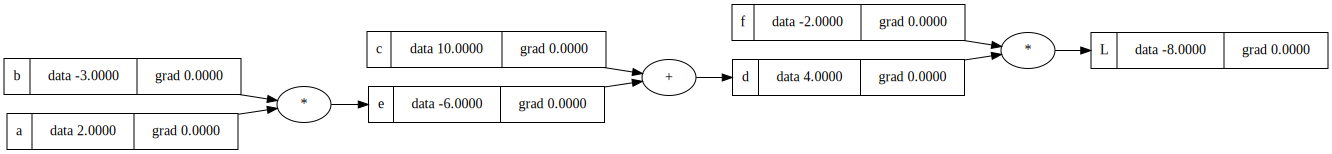

In [97]:
draw_dot(L)

AttributeError: 'Value' object has no attribute 'backward'

In [79]:
a.grad = e.grad * b.data
b.grad = e.grad * a.data

In [80]:
a.data += 0.1 * a.grad
b.data += 0.1 * b.grad
c.data += 0.1 * c.grad
f.data += 0.1 * f.grad

e = a *b ; 
d = e+c; 
L = d * f;



In [81]:
L

Value(data=-8.0, op=*)

In [82]:
def lol():
    h =0.0001
    a = Value(2.0, label = 'a')
    b = Value(-3.0, label = 'b')
    c = Value(10.0, label = 'c')
    e = a *b ; e.label = 'e'
    d = e+c; d.label = 'd'
    f = Value(-2, label = 'f')
    L = d * f; L.label = 'L'
    L1 = L.data

    a = Value(2.0 + h, label = 'a')
    b = Value(-3.0, label = 'b')
    c = Value(10.0, label = 'c')
    e = a *b ; e.label = 'e'
    d = e+c; d.label = 'd'
    f = Value(-2, label = 'f')
    L = d * f; L.label = 'L'
    L2 = L.data

    print((L2- L1) /h)

lol()

6.000000000021544


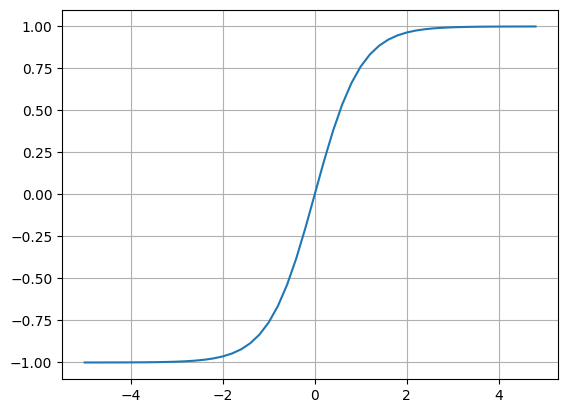

In [83]:
plt.plot(np.arange(-5,5, 0.2), np.tanh(np.arange(-5,5, 0.2)))
plt.grid()

In [100]:
x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')
b = Value(6.8813735870195432, label = 'b')

x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n= x1w1x2w2 + b; n.label = 'n'
o = n.tanh()


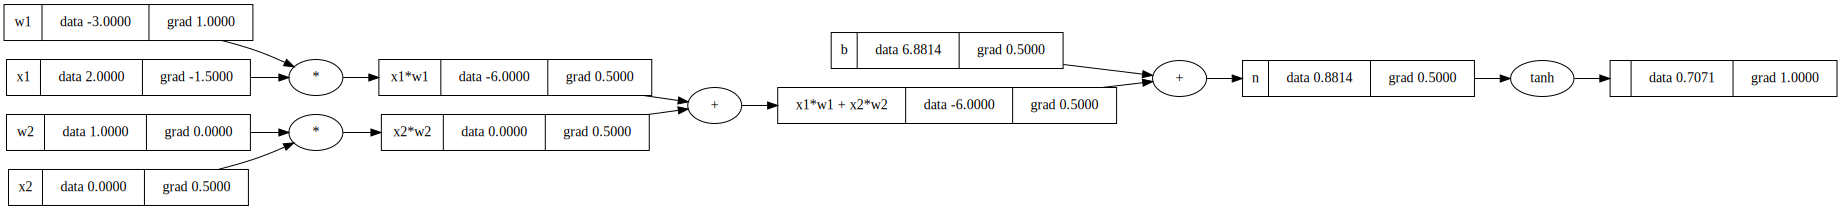

In [103]:
draw_dot(o)

In [102]:
o.backward()

In [104]:
# # topological sort
# topo = []
# visited = set()
# def build_topo(v):
#     if v not in visited:
#         visited.add(v)
#         topo.append(v) # reverse (noramlly after the for)
#         for child in v._prev:
#             build_topo(child)
        
# build_topo(o)
# topo

In [105]:
# o.grad = 1
# for t in topo:
#     t._backward()

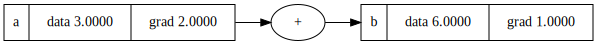

In [108]:
a =  Value(3, label = 'a')
b = a + a; b.label = 'b'
b.backward()
draw_dot(b)